## Examen Módulo 4
## Alumno: Salvador Calderón Martínez

## 1. Ingeniería de Datos, Integración (Join) y Publicación en la Nube (Parte 1)

In [104]:
import pandas as pd

## Cargar datos


In [105]:
personal = pd.read_csv("https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv")
personal


,Laureate_Id,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,1011,Svante,Pääbo,male,20/04/1955,Sweden,Stockholm,SE,0000-00-00,NaN,NaN,NaN,Max Planck Institute for Evolutionary Anthropo...,Leipzig,Germany
985,743,Barry,Sharpless,male,28/04/1941,USA,Philadelphia PA,US,0000-00-00,NaN,NaN,NaN,Scripps Research,La Jolla CA,USA
986,1022,Douglas,Diamond,male,25/10/1953,USA,Chicago IL,US,0000-00-00,NaN,NaN,NaN,University of Chicago,Chicago IL,USA
987,1015,Carolyn,Bertozzi,female,10/10/1966,USA,Boston MA,US,0000-00-00,NaN,NaN,NaN,Stanford University,Stanford CA,USA


In [106]:
premios = pd.read_csv("https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_data.csv")
premios

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ..."
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ..."
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ..."
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace..."
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit..."
...,...,...,...,...,...,...,...
984,2022,1011,Svante,Pääbo,medicine,1,"""for his discoveries concerning the genomes of..."
985,2022,743,Barry,Sharpless,chemistry,3,"""for the development of click chemistry and bi..."
986,2022,1022,Douglas,Diamond,economics,3,"""for research on banks and financial crises"""
987,2022,1015,Carolyn,Bertozzi,chemistry,3,"""for the development of click chemistry and bi..."


## Datos nulos

In [107]:
print(personal.isna().sum())

Laureate_Id               0
Firstname                 0
Lastname                 32
Gender                    0
Birth_Date                0
Birth_Country            31
Birth_City               33
Birth_Country_Code       31
Death_Date                0
Death_Country           343
Death_City              349
Death_Country_Code      343
Organization_Name       262
Organization_City       267
Organization_Country    265
dtype: int64


In [108]:
print(premios.isna().sum())

Year            0
Laureate_Id     0
Firstname       0
Lastname       32
Category        0
Prize_Share     0
Motivation      0
dtype: int64


## Datos duplicados

In [109]:
print(premios.duplicated().sum())

0


In [110]:
print(personal.duplicated().sum())

5


In [111]:
personal["Laureate_Id"].duplicated().sum()

np.int64(8)

In [112]:
premios["Laureate_Id"].duplicated().sum()


np.int64(8)

## Limpieza

In [113]:
# Apellido vacío se le agrega "unknown" para no perder información
personal["Lastname"] = personal["Lastname"].fillna("unknown")
premios["Lastname"] = premios["Lastname"].fillna("unknown")

# Quitar espacios
personal["Firstname"] = personal["Firstname"].str.strip()
personal["Lastname"] = personal["Lastname"].str.strip()
premios["Firstname"] = premios["Firstname"].str.strip()
premios["Lastname"] = premios["Lastname"].str.strip()

In [114]:
# Elimnar duplicados en el id principal de personal
personal = personal.drop_duplicates(subset="Laureate_Id")
personal.shape

(981, 15)

In [115]:
# Elimine la columna con Laureate_Id de la tabla persona por que cuando
# la uni entra en conflicto con la misma columna de la tabla premio

personal = personal.drop(columns="Laureate_Id")

In [116]:
# Las fechas estan en diferentes formatos, se arreglaran para cuando se usen en PowerBI.
personal["Birth_Year"] = personal["Birth_Date"].str.extract(r"(\d{4})").astype(float)
personal["Death_Year"] = personal["Death_Date"].str.extract(r"(\d{4})").astype(float)

# Algunos valores de año de nacimiento y muerte son 0, le asigne None
personal.loc[personal["Birth_Year"] == 0, "Birth_Year"] = None
personal.loc[personal["Death_Year"] == 0, "Death_Year"] = None


## Realizar el Join

In [117]:
nobel = premios.merge(personal, on=["Firstname", "Lastname"], how="left")
nobel.head()

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation,Gender,Birth_Date,Birth_Country,...,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Birth_Year,Death_Year
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ...",male,1845-03-27,Prussia (now Germany),...,DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1845.0,1923.0
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ...",male,1854-03-15,Prussia (now Poland),...,PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1854.0,1917.0
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ...",male,1828-05-08,Switzerland,...,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1828.0,1910.0
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace...",male,1822-05-20,France,...,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1822.0,1912.0
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit...",male,1839-03-16,France,...,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1839.0,1907.0


In [118]:
nobel.to_csv("nobelsalvador_limpio.csv", index=False)

In [119]:
# Mostrar archivo raw
pd.read_csv("https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/refs/heads/main/nobelsalvador_limpio.csv")

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation,Gender,Birth_Date,Birth_Country,...,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Birth_Year,Death_Year
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ...",male,1845-03-27,Prussia (now Germany),...,DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1845.0,1923.0
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ...",male,1854-03-15,Prussia (now Poland),...,PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1854.0,1917.0
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ...",male,1828-05-08,Switzerland,...,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1828.0,1910.0
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace...",male,1822-05-20,France,...,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1822.0,1912.0
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit...",male,1839-03-16,France,...,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1839.0,1907.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,2022,1011,Svante,Pääbo,medicine,1,"""for his discoveries concerning the genomes of...",male,20/04/1955,Sweden,...,SE,0000-00-00,NaN,NaN,NaN,Max Planck Institute for Evolutionary Anthropo...,Leipzig,Germany,1955.0,NaN
985,2022,743,Barry,Sharpless,chemistry,3,"""for the development of click chemistry and bi...",male,28/04/1941,USA,...,US,0000-00-00,NaN,NaN,NaN,The Scripps Research Institute,La Jolla CA,USA,1941.0,NaN
986,2022,1022,Douglas,Diamond,economics,3,"""for research on banks and financial crises""",male,25/10/1953,USA,...,US,0000-00-00,NaN,NaN,NaN,University of Chicago,Chicago IL,USA,1953.0,NaN
987,2022,1015,Carolyn,Bertozzi,chemistry,3,"""for the development of click chemistry and bi...",female,10/10/1966,USA,...,US,0000-00-00,NaN,NaN,NaN,Stanford University,Stanford CA,USA,1966.0,NaN


## 2. Procesamiento de Lenguaje Natural (ETL de Texto y Visualización)

In [120]:
!pip install wordcloud -q

In [121]:

import re
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

premios = pd.read_csv("https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/refs/heads/main/nobelsalvador_limpio.csv")
premios.groupby("Category")["Motivation"].describe()

,count,unique,top,freq
Category,,,,
chemistry,191,128,"""for their studies of extremely fast chemical ...",3
economics,92,60,"""for their pioneering work in the theory of fi...",3
literature,119,119,"""in special recognition of his poetic composit...",1
medicine,225,126,"""for their discoveries concerning liver therap...",3
peace,140,110,"""for their efforts to create peace in the Midd...",3
physics,222,141,"""for their researches on semiconductors and th...",3


In [122]:
# Nulos en Motivation
("Nulos en Motivation:", premios["Motivation"].isna().sum())

texto_df = premios.dropna(subset=["Motivation"]).copy()
print("Filas utilizables:", texto_df.shape[0])

Filas utilizables: 989


## 3. Limpieza y normalización del texto

In [123]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords_en = set(STOPWORDS) | set(ENGLISH_STOP_WORDS)

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)   # quita puntuación, números y caracteres especiales
    texto = re.sub(r"\s+", " ", texto).strip()
    palabras = [w for w in texto.split() if w not in stopwords_en and len(w) > 2]
    return " ".join(palabras)

texto_df["Motivation_limpio"] = texto_df["Motivation"].apply(limpiar_texto)
texto_df[["Motivation", "Motivation_limpio"]].head()

,Motivation,Motivation_limpio
0,"""in recognition of the extraordinary services ...",recognition extraordinary services rendered di...
1,"""for his work on serum therapy especially its ...",work serum therapy especially application diph...
2,"""for his humanitarian efforts to help wounded ...",humanitarian efforts help wounded soldiers cre...
3,"""for his lifelong work for international peace...",lifelong work international peace conferences ...
4,"""in special recognition of his poetic composit...",special recognition poetic composition gives e...


In [124]:
# Vectorización

# Corpus unificado para la nube de palabras
corpus_completo = " ".join(texto_df["Motivation_limpio"])
print("Total de palabras en el corpus:", len(corpus_completo.split()))

# Frecuencia de palabras (para revisar antes de graficar)
frecuencias = Counter(corpus_completo.split())
print("Top 15 palabras más frecuentes:")
for palabra, conteo in frecuencias.most_common(15):
    print(f"  {palabra}: {conteo}")

Total de palabras en el corpus: 7631
Top 15 palabras más frecuentes:
  discovery: 200
  discoveries: 162
  concerning: 116
  work: 105
  development: 105
  theory: 72
  contributions: 60
  structure: 56
  peace: 52
  recognition: 48
  economic: 45
  chemical: 43
  analysis: 42
  human: 42
  new: 40


In [125]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(max_features=3000, min_df=2)
X_tfidf = vectorizador.fit_transform(texto_df["Motivation_limpio"])
print("Matriz TF-IDF:", X_tfidf.shape)

Matriz TF-IDF: (989, 1197)


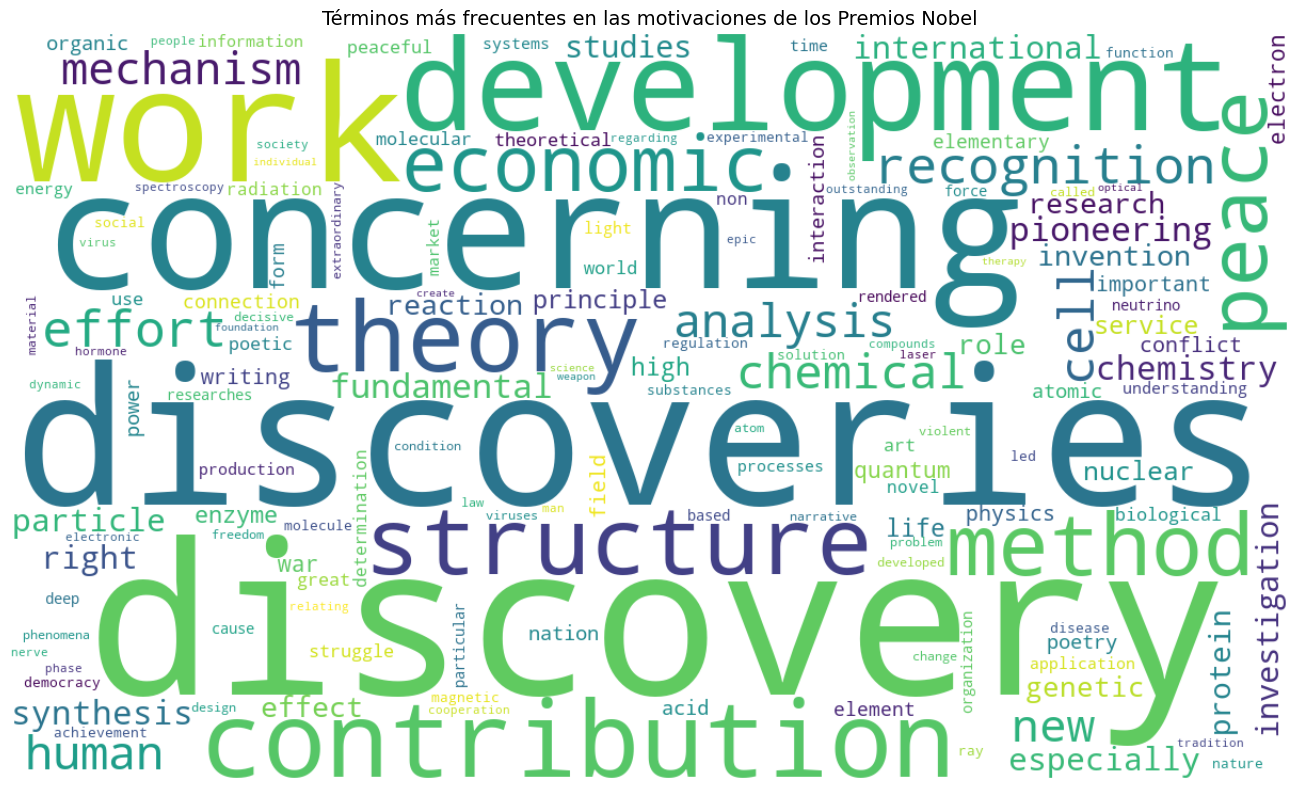

In [126]:
# Nube de palabras 
nube = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    stopwords=stopwords_en,
    colormap="viridis",
    max_words=150,
    collocations=False,   # evita repetir pares de palabras como una sola "palabra"
).generate(corpus_completo)

plt.figure(figsize=(14, 8))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Términos más frecuentes en las motivaciones de los Premios Nobel", fontsize=14)
plt.tight_layout()
plt.savefig("nube_palabras_nobel.png", dpi=150, bbox_inches="tight")
plt.show()

## Modelo

## APP

In [127]:
import numpy as np
import streamlit as st
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


st.write(''' # Predicción de categoría de Premio Nobel ''')
st.image("Nobel.png", caption="Su creador fue el inventor sueco Alfred Nobel mediante su testamento en 1895.")

st.header('Texto')

def user_input_features():
  # Entrada
  texto = st.text_input("Introduce el texto a evaluar")

  user_input_data = {'Text': texto}

  features = pd.DataFrame(user_input_data, index=[0])

  return features

df = user_input_features()

nobel =  pd.read_csv('df_nobel.csv', encoding='latin-1')
X = nobel.Text
y = nobel.Label

vect = CountVectorizer()
X_dtm = vect.fit_transform(X)

nb = MultinomialNB()
nb.fit(X_dtm, y)

df_dtm = vect.transform(df['Text'])
prediction = nb.predict(df_dtm)

#{'physics':0, 'medicine':1, 'peace':2, 'literature':3, 'chemistry':4, 'economics':5}
#'Physics', 'Medicine', 'Peace', 'Literature', 'Chemistry', 'Economics'
st.subheader('Predicción')
if prediction == 0:
  st.write('Physics')
elif prediction == 1:
  st.write('Medicine')
elif prediction == 2:
  st.write('Peace')
elif prediction == 3:
  st.write('Literature')
elif prediction == 4:
  st.write('Chemistry')
elif prediction == 5:
  st.write('Economics')
else:
  st.write('Sin predicción')


2026-09-20 14:37:10.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 14:37:10.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 14:37:10.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 14:37:10.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


RuntimeError: Runtime hasn't been created!